# D2 — Technology Adoption Forecasting

Reads ARIMA forecast results from GCS, runs **Prophet locally** to fill the
`prophet_*` columns, and produces per-language forecast plots.

- ARIMA forecasts were generated by the Dataproc Spark job (`d2_forecasting.py`)
- Prophet runs here inside the local `.venv` where `cmdstanpy` is available

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

os.environ['GOOGLE_APPLICATION_CREDENTIALS'] = '../service-account-key.json'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from prophet import Prophet

BUCKET = 'github-tech-trends-data'
sns.set_theme(style='whitegrid')
print('Environment ready (Prophet available).')

Environment ready (Prophet available).


In [ ]:
import subprocess, sys
# Ensure CmdStan is installed for Prophet
try:
    import cmdstanpy
    cmdstanpy.cmdstan_path()
except (ValueError, Exception):
    import cmdstanpy
    cmdstanpy.install_cmdstan()


## 1. Load ARIMA results from GCS

In [2]:
df = pd.read_parquet(f'gs://{BUCKET}/processed/d2_forecasts/')
df['date'] = pd.to_datetime(df['year_month'] + '-01')
# Exclude partial 2026 historical data; keep forecast rows (is_forecast=True goes past 2025)
df = df[(df['year_month'] <= '2025-12') | (df['is_forecast'] == True)]
df = df.sort_values(['language', 'date'])

languages = sorted(df['language'].unique())
print(f'Rows: {len(df):,}  |  Languages: {len(languages)}')
print('Columns:', df.columns.tolist())
df.head(3)

Rows: 4,770  |  Languages: 30
Columns: ['language', 'year_month', 'actual', 'prophet_yhat', 'prophet_lower', 'prophet_upper', 'arima_yhat', 'is_forecast', 'date']


,language,year_month,actual,prophet_yhat,prophet_lower,prophet_upper,arima_yhat,is_forecast,date
259,c,2015-01,6951.0,NaN,NaN,NaN,NaN,False,2015-01-01
2163,c,2015-02,7296.0,NaN,NaN,NaN,NaN,False,2015-02-01
1230,c,2015-03,8224.0,NaN,NaN,NaN,NaN,False,2015-03-01


## 2. Run Prophet locally to fill prophet_* columns

In [3]:
FORECAST_PERIODS = 24  # months forward

prophet_results = []

for lang in languages:
    sub = df[df['language'] == lang].copy()
    hist = sub[~sub['is_forecast']].dropna(subset=['actual'])

    if len(hist) < 24:
        # Not enough history — keep NaN prophet columns
        prophet_results.append(sub)
        continue

    try:
        ph_df = hist[['date', 'actual']].rename(columns={'date': 'ds', 'actual': 'y'})
        m = Prophet(yearly_seasonality=True, weekly_seasonality=False,
                    daily_seasonality=False, interval_width=0.95)
        m.fit(ph_df)

        future = m.make_future_dataframe(periods=FORECAST_PERIODS, freq='MS')
        forecast = m.predict(future)
        forecast['year_month'] = forecast['ds'].dt.strftime('%Y-%m')

        fc_map = forecast.set_index('year_month')[['yhat', 'yhat_lower', 'yhat_upper']].to_dict('index')

        sub['prophet_yhat']  = sub['year_month'].map(lambda ym: fc_map.get(ym, {}).get('yhat', np.nan))
        sub['prophet_lower'] = sub['year_month'].map(lambda ym: fc_map.get(ym, {}).get('yhat_lower', np.nan))
        sub['prophet_upper'] = sub['year_month'].map(lambda ym: fc_map.get(ym, {}).get('yhat_upper', np.nan))
    except Exception as e:
        print(f'Prophet failed for {lang}: {e}')

    prophet_results.append(sub)

df_full = pd.concat(prophet_results, ignore_index=True)
print('Prophet complete. Non-NaN prophet_yhat rows:',
      df_full['prophet_yhat'].notna().sum())

Prophet failed for c: 'Prophet' object has no attribute 'stan_backend'
Prophet failed for c#: 'Prophet' object has no attribute 'stan_backend'
Prophet failed for c++: 'Prophet' object has no attribute 'stan_backend'
Prophet failed for dart: 'Prophet' object has no attribute 'stan_backend'
Prophet failed for elixir: 'Prophet' object has no attribute 'stan_backend'
Prophet failed for go: 'Prophet' object has no attribute 'stan_backend'
Prophet failed for haskell: 'Prophet' object has no attribute 'stan_backend'
Prophet failed for hcl: 'Prophet' object has no attribute 'stan_backend'
Prophet failed for java: 'Prophet' object has no attribute 'stan_backend'
Prophet failed for javascript: 'Prophet' object has no attribute 'stan_backend'
Prophet failed for julia: 'Prophet' object has no attribute 'stan_backend'
Prophet failed for jupyter notebook: 'Prophet' object has no attribute 'stan_backend'
Prophet failed for kotlin: 'Prophet' object has no attribute 'stan_backend'
Prophet failed for lu

## 3. Forecast overview — ARIMA vs Prophet (selected languages)

In [4]:
# Pick 6 languages with the largest forecast-period ARIMA increase
fc_delta = (
    df_full[df_full['is_forecast']]
    .groupby('language')['arima_yhat']
    .mean()
    - df_full[~df_full['is_forecast']]
    .groupby('language')['actual']
    .mean()
).sort_values(ascending=False)

top6 = fc_delta.head(6).index.tolist()
print('Top 6 highest-growth languages:', top6)

Top 6 highest-growth languages: ['go', 'rust', 'typescript', 'nix', 'powershell', 'hcl']


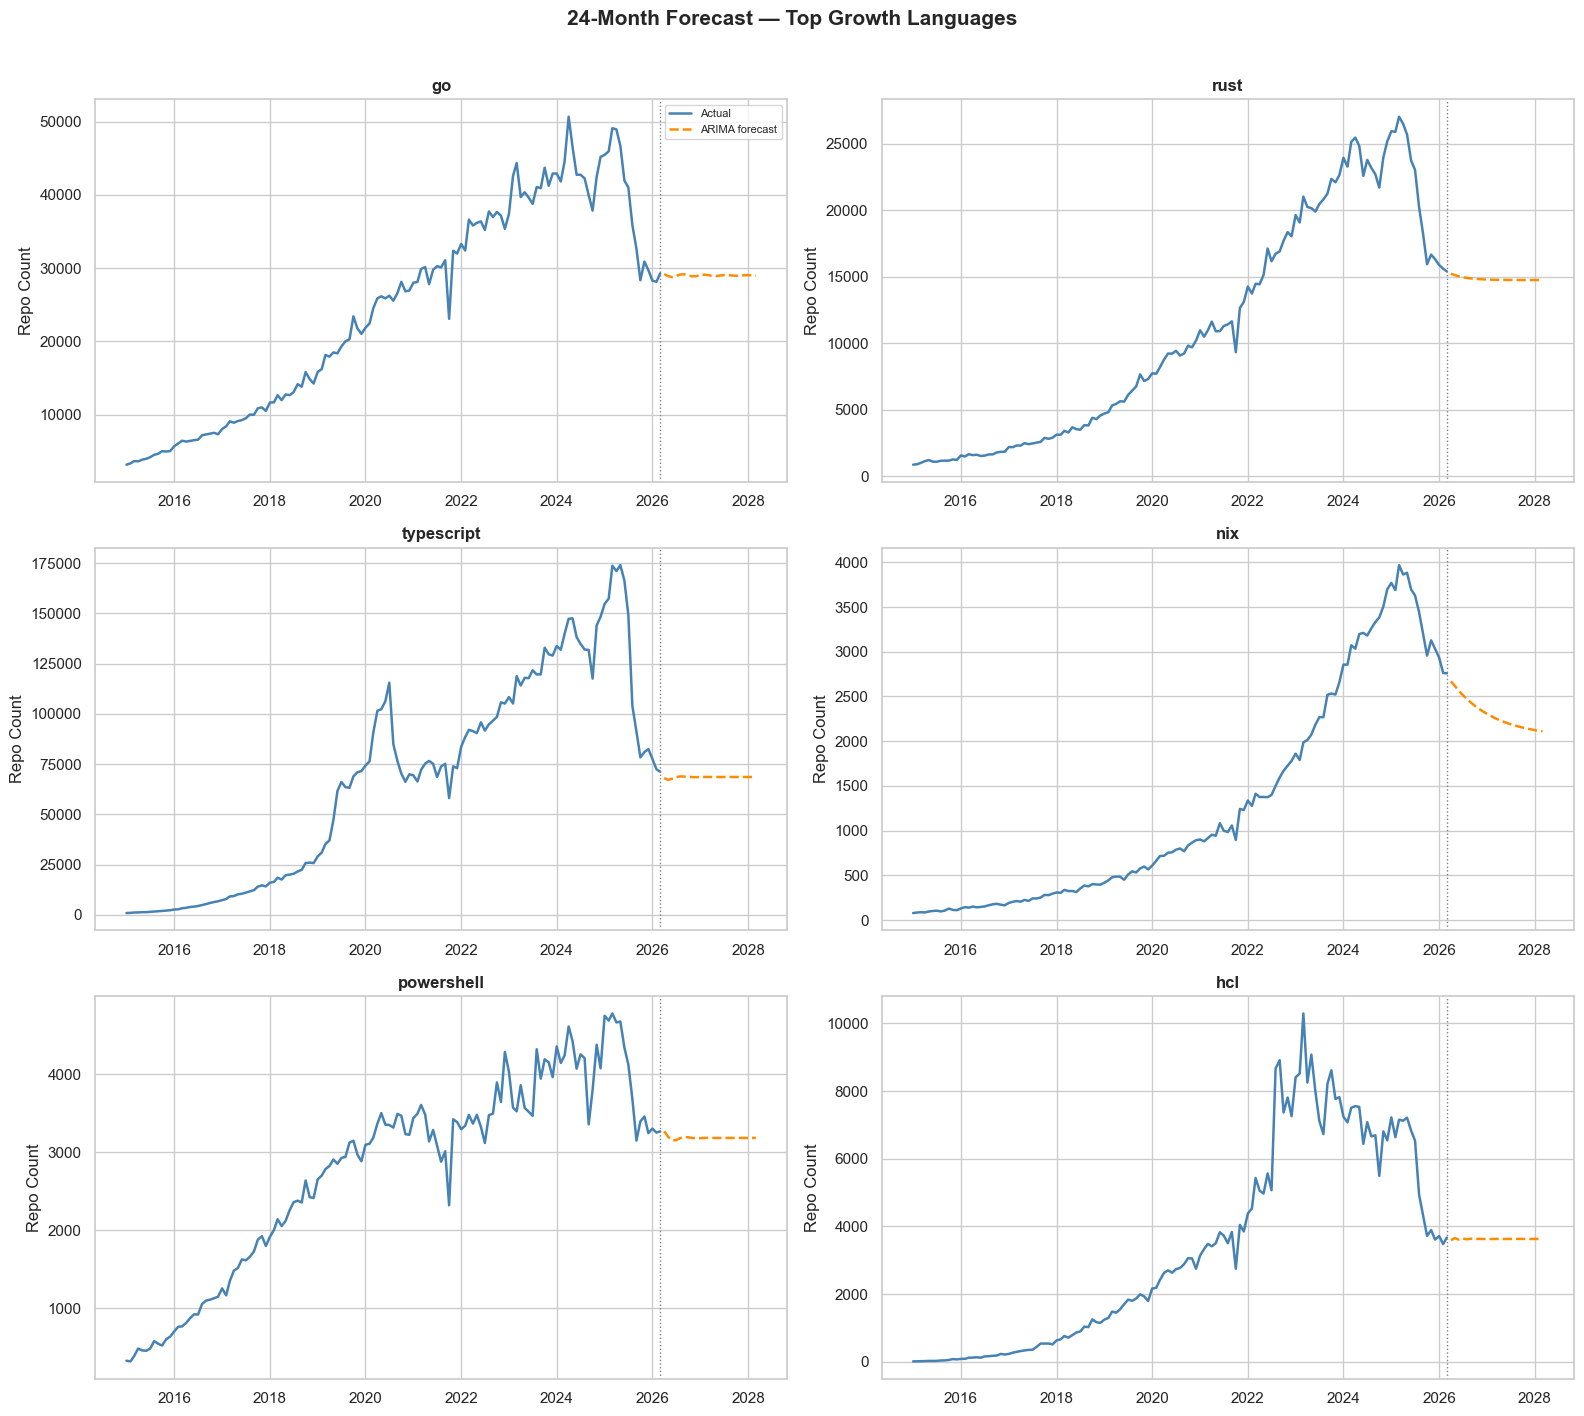

In [5]:
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

for idx, lang in enumerate(top6):
    ax = axes[idx]
    sub = df_full[df_full['language'] == lang].copy()
    hist = sub[~sub['is_forecast']]
    fc   = sub[sub['is_forecast']]

    # Actual history
    ax.plot(hist['date'], hist['actual'], color='steelblue',
            linewidth=1.8, label='Actual')

    # ARIMA forecast
    ax.plot(fc['date'], fc['arima_yhat'], color='darkorange',
            linewidth=1.8, linestyle='--', label='ARIMA forecast')

    # Prophet forecast + confidence band
    if fc['prophet_yhat'].notna().any():
        ax.plot(fc['date'], fc['prophet_yhat'], color='green',
                linewidth=1.8, linestyle=':', label='Prophet forecast')
        ax.fill_between(fc['date'], fc['prophet_lower'], fc['prophet_upper'],
                        alpha=0.15, color='green', label='Prophet 95% CI')

    ax.axvline(hist['date'].max(), color='grey', linestyle=':', linewidth=1)
    ax.set_title(lang, fontsize=12, fontweight='bold')
    ax.set_ylabel('Repo Count')
    if idx == 0:
        ax.legend(fontsize=8)

plt.suptitle('24-Month Forecast — Top Growth Languages', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/d2_top6_forecasts.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. All-languages ARIMA forecast summary (final forecast value)

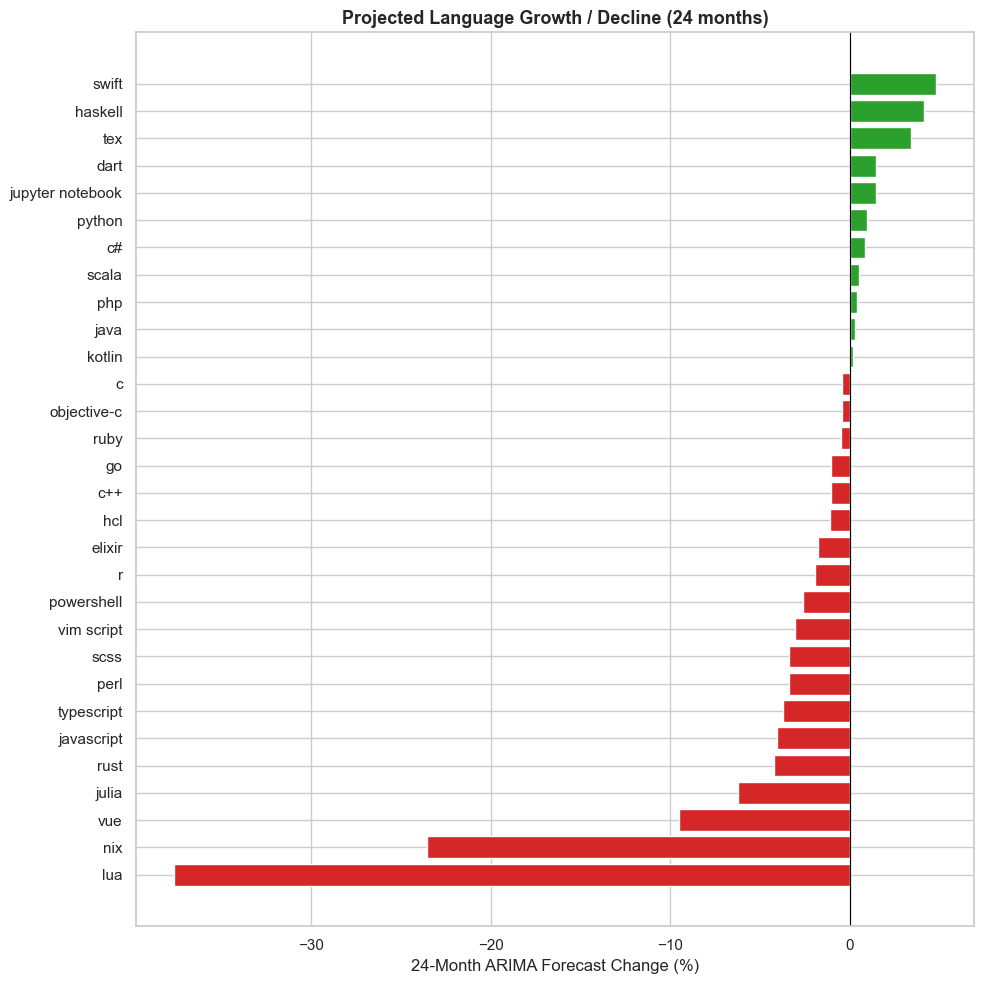

In [6]:
last_actual = (
    df_full[~df_full['is_forecast']]
    .groupby('language')['actual'].last()
    .rename('last_actual')
)
last_forecast = (
    df_full[df_full['is_forecast']]
    .groupby('language')['arima_yhat'].last()
    .rename('arima_24m')
)

summary = pd.concat([last_actual, last_forecast], axis=1).dropna()
summary['pct_change'] = (summary['arima_24m'] - summary['last_actual']) / summary['last_actual'] * 100
summary = summary.sort_values('pct_change', ascending=True)

fig, ax = plt.subplots(figsize=(10, 10))
colors = ['#d62728' if v < 0 else '#2ca02c' for v in summary['pct_change']]
ax.barh(summary.index, summary['pct_change'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('24-Month ARIMA Forecast Change (%)')
ax.set_title('Projected Language Growth / Decline (24 months)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/d2_forecast_summary.png', dpi=150)
plt.show()

## 5. Heatmap — monthly repo count by language

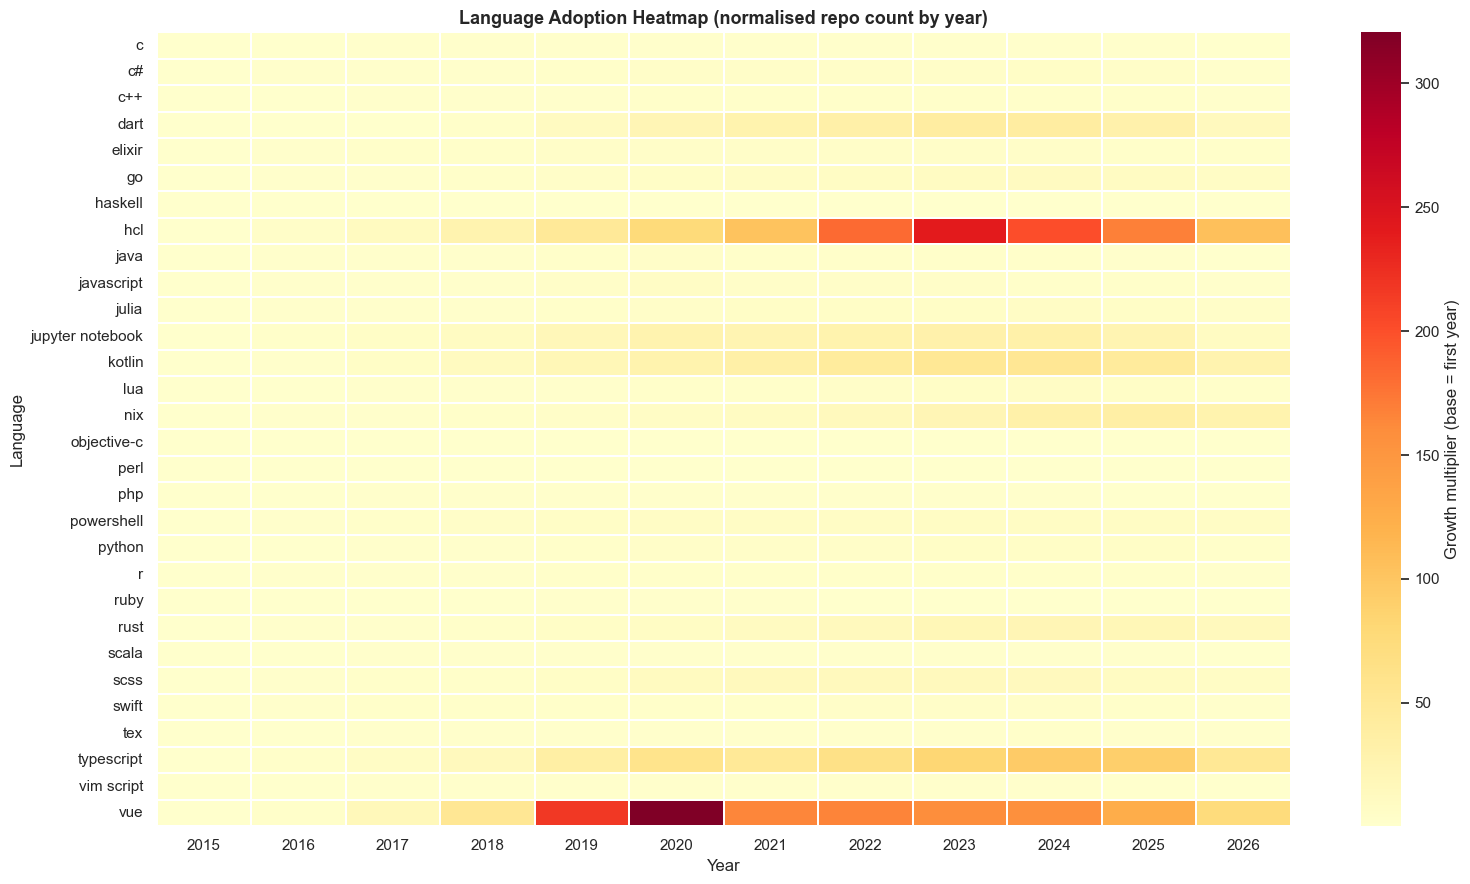

In [7]:
# Pivot: rows=language, cols=year, values=avg monthly repo_count
df_full['year'] = df_full['date'].dt.year
pivot = (
    df_full[~df_full['is_forecast']]
    .groupby(['language', 'year'])['actual'].mean()
    .unstack('year')
)

# Normalise each language so all start at 1 for comparability
pivot_norm = pivot.div(pivot.iloc[:, 0], axis=0)

fig, ax = plt.subplots(figsize=(16, 9))
sns.heatmap(pivot_norm, cmap='YlOrRd', ax=ax, linewidths=0.3,
            linecolor='white', fmt='.1f', annot=False,
            cbar_kws={'label': 'Growth multiplier (base = first year)'})
ax.set_title('Language Adoption Heatmap (normalised repo count by year)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Language')
ax.set_xlabel('Year')
plt.tight_layout()
plt.savefig('../outputs/d2_adoption_heatmap.png', dpi=150)
plt.show()